<>:46: SyntaxWarning: invalid escape sequence '\s'
<>:46: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2998/250121309.py:46: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel('$\sqrt{2}x_1x_2$')


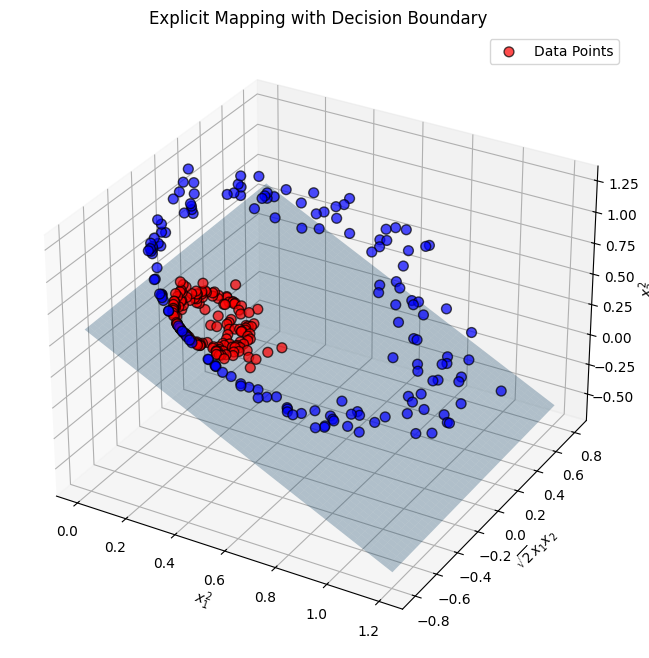

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_circles

# 1. Generate Data (Concentric Circles for Non-Linear Separation)
np.random.seed(42)
X, y = make_circles(n_samples=300, factor=0.5, noise=0.05)

# Convert labels from (0,1) to (-1,1) for SVM
y = np.where(y == 0, -1, 1)

# Trandform data by applying phi(x) to each point
phi_X = np.array([[x[0]**2, np.sqrt(2)*x[0]*x[1], x[1]**2] for x in X])

# 2. Train a linear SVM classifier for transformed phi_X
clf = SVC(kernel='linear', C=1e5)
clf.fit(phi_X, y)

# Get coefficients to calculate decision boundary (separating hyperplane)
w = clf.coef_[0]
b = clf.intercept_[0]

# Create grid in z1, z2
z1_range = np.linspace(phi_X[:,0].min(), phi_X[:,0].max(), 50)
z2_range = np.linspace(phi_X[:,1].min(), phi_X[:,1].max(), 50)
z1, z2 = np.meshgrid(z1_range, z2_range)

# Compute z3 from plane equation
z3 = (-b - w[0]*z1 - w[1]*z2) / w[2]

# 3D Plot for phi(x) with Decision Boundary
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot surface
ax.plot_surface(z1, z2, z3, alpha=0.3)


# Scatter plot of transformed data
ax.scatter(phi_X[:, 0], phi_X[:, 1], phi_X[:, 2], c=y, cmap='bwr', edgecolors='k', s=50, alpha=0.7, label='Data Points')

# Set axis labels and title for 3D plot
ax.set_title('Explicit Mapping with Decision Boundary')
ax.set_xlabel('$x_1^2$')
ax.set_ylabel('$\sqrt{2}x_1x_2$')
ax.set_zlabel('$x_2^2$')

# Add legend and grid
ax.legend()
ax.grid(True)

plt.show()

SVM learned coefficients for

 $w_1z_1+w_2z_2+w_3z_3=0$

We can now use them to find the preimage by checking which points after transformation are close to the decision boundary.
The preimage of the hyperplane is the set of points in
$\mathbb{𝑅^2}$
 satisfying a quadratic equation.
It is a conic section, and in this dataset it corresponds to a circle/ellipse separating the classes

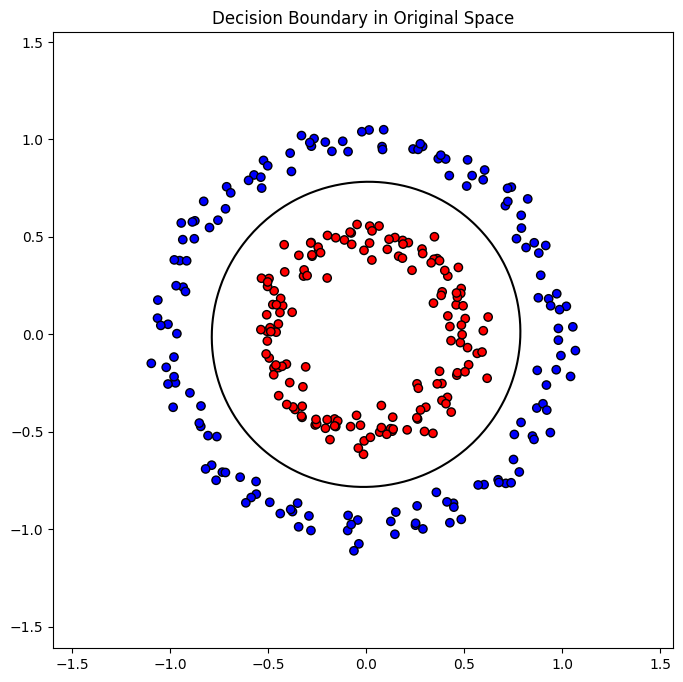

In [2]:
# Create grid to find the preimage of hyperplane
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 100),
    np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 100)
)

# Get coefficients from hyperplane
w = clf.coef_[0]
b = clf.intercept_[0]
# Z is the score assigned to point on the hyperplane. We look for points close to 0.
Z = (
    w[0]*xx**2 +
    w[1]*np.sqrt(2)*xx*yy +
    w[2]*yy**2 +
    b
)

# Plot original data and decision boundary preimage
plt.figure(figsize=(8,8))
# Draw a contour from points closest to level Z = 0
plt.contour(xx, yy, Z, levels=[0], colors='black')
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolors='k')
plt.title("Decision Boundary in Original Space")
plt.show()

#Why does the boundary NOT look flat in 2D
The decision boundary is not flat because the transformation is not linear. It is a quadratic transformation of a linear space which converts linear space into conic curves. The same goes for the inverse. The preimage becomes a conic section.
#Geometric intuition
The image of $\phi$ is a curved surface. The SVM finds a flat plan in this curved surface. Then the projecting it back on a flat surface creates a curve.

#Why specifically a circle here?

Because:

1. Data is concentric circles
2. SVM finds symmetric solution
3. coefficients are almost the same, so ellipse becomes a circle


#Why is it useful?
In kernel SVM, we do not explicitly transform data into a higher-dimensional space. Instead, we use a kernel function to compute inner products in that space implicitly. The classifier is linear in the feature space, but predictions for new points are made using kernel evaluations with support vectors, without ever computing the transformed coordinates. This allows us to use the benefits of higher dimensional space (linear SVM) without heavy computations.